## Generating Initial Particle Configuration

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
L = 19
N = 108


gen_particles=[]
while(len(gen_particles)<N):
    flag=0
    x=random.uniform(0, L)
    y=random.uniform(0, L)
    z=random.uniform(0, L)
    for p in gen_particles:
        dx=abs(x-p[0])
        dy=abs(y-p[1])
        dz=abs(z-p[2])
        if dx>L/2:
            dx=L-dx
        if dy>L/2:
            dy=L-dy
        if dz>L/2:
            dz=L-dz
        if np.sqrt(dx**2 + dy**2 + dz**2) < 3:
            flag=1
            break
    if flag==0:
        gen_particles.append((x,y,z))

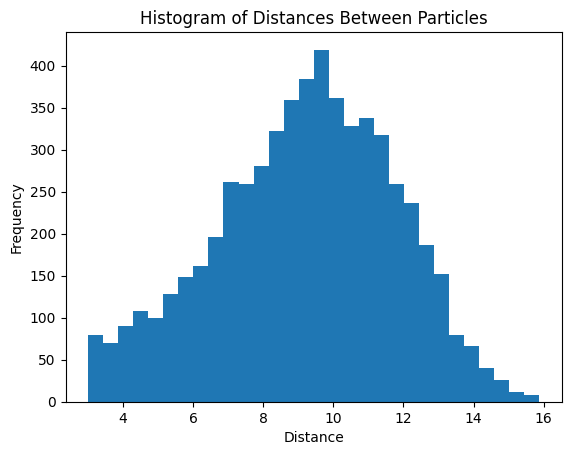

In [3]:
dist=[]
for p in range(len(gen_particles)):
    for q in range(p+1,len(gen_particles)):
        dx=abs(gen_particles[p][0]-gen_particles[q][0])
        dy=abs(gen_particles[p][1]-gen_particles[q][1])
        dz=abs(gen_particles[p][2]-gen_particles[q][2])
        if dx>L/2:
            dx=L-dx
        if dy>L/2:
            dy=L-dy
        if dz>L/2:
            dz=L-dz
        dist.append(np.sqrt(dx**2 + dy**2 + dz**2))

plt.hist(dist, bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Distances Between Particles')
plt.show()


### **Result & Inference: Histogram of Distances Between Particles**

This histogram displays the distribution of pairwise distances between all particles in the initial configuration. The x-axis represents the distance (in Ångströms) between particle pairs, while the y-axis shows the frequency (count) of particle pairs at each distance.

**Key Observations:**
- **Minimum Distance Exclusion**: The histogram shows a sharp cutoff at approximately 3 Å, indicating that no particles exist closer than this distance. This is by design—during particle generation, we enforced a minimum separation of 3 Å to prevent unrealistic particle overlaps and ensure a physically valid initial state.
- **Distribution Shape**: The distribution appears roughly unimodal and skewed toward larger distances, which is expected in a random particle packing within a cubic box. Most particle pairs are at intermediate to larger distances, with fewer close pairs and fewer very distant pairs.
- **Physical Meaning**: This distance distribution is representative of a quasi-random, disordered liquid-like state. In a perfect crystal, particles would show sharp peaks at specific lattice distances. In contrast, this smooth distribution reflects the amorphous nature of our initial configuration, similar to what you'd find in a supercooled liquid or amorphous solid.

# Monte Carlo Simulation

The Monte Carlo (MC) simulation implemented here uses the Metropolis algorithm in the NVT (canonical) ensemble, where the number of particles (N), volume (V), and temperature (T) are kept constant. The goal is to sample configurations from the Boltzmann distribution to find low-energy states.

The simulation follows these steps:

1.  **Initialization**:
    *   The system starts with the initial particle configuration generated previously.
    *   The total potential energy of this initial state is calculated using the Lennard-Jones potential, which models the interaction between pairs of particles. Periodic boundary conditions are applied using the minimum image convention to simulate an infinite system.

2.  **Trial Move**:
    *   In each step of the simulation, a random particle is chosen.
    *   This particle is given a small, random displacement in x, y, and z directions. The maximum displacement is controlled by the step size `delta`.
    *   If the move takes the particle outside the simulation box, it is wrapped around to the other side (periodic boundary condition).

3.  **Metropolis Acceptance Criterion**:
    *   The change in potential energy (`delta_u`) resulting from the trial move is calculated.
    *   This move is accepted or rejected based on the following rules:
        *   If the move results in a lower energy state (`delta_u < 0`), it is **always accepted**. The system naturally prefers to move to lower energy states.
        *   If the move results in a higher energy state (`delta_u > 0`), it is accepted with a probability of `exp(-delta_u / (k * T))`, where `k` is the Boltzmann constant and `T` is the temperature. This allows the system to occasionally overcome energy barriers and escape local minima, which is crucial for exploring the entire configuration space.

4.  **System Evolution**:
    *   If the move is **accepted**, the new particle configuration is kept, and the total energy of the system is updated.
    *   If the move is **rejected**, the particle is moved back to its original position, and the configuration and energy remain unchanged.

This process is repeated for a large number of trials, gradually guiding the system towards states of thermal equilibrium.

## Initial Configuration

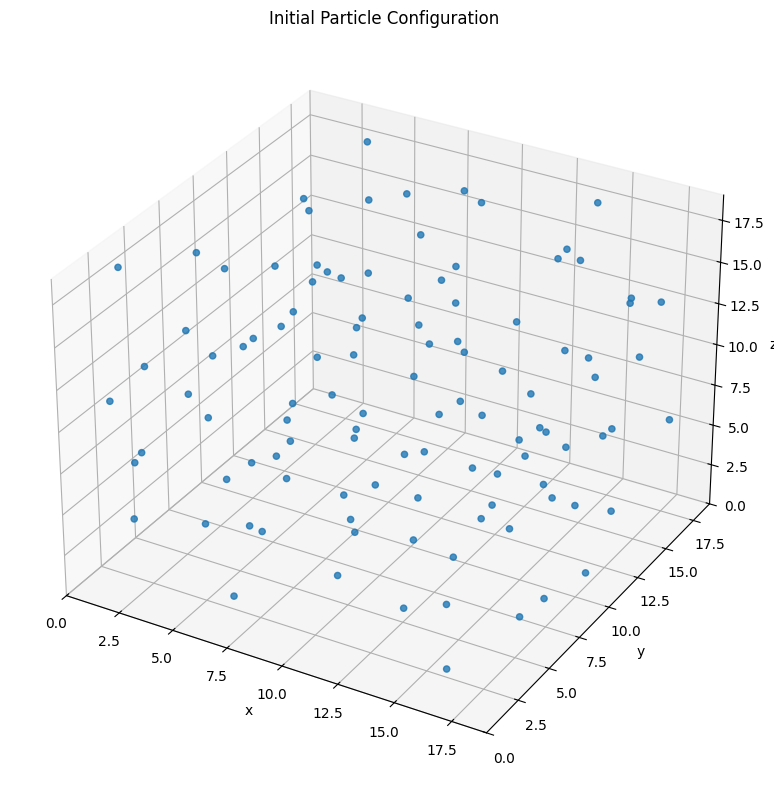

In [4]:
particles = np.array(gen_particles)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(particles[:, 0], particles[:, 1], particles[:, 2], s=20, alpha=0.8)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Particle Configuration")
plt.tight_layout()
plt.show()

## Running Monte Carlo Simulation

In [5]:
epsilon = 0.238
sigma = 3.4
def calculate_energy(gen_particles, sigma, epsilon):
    u=0
    for p in range(len(gen_particles)):
        for q in range(p+1,len(gen_particles)):
            dx=abs(gen_particles[p][0]-gen_particles[q][0])
            dy=abs(gen_particles[p][1]-gen_particles[q][1])
            dz=abs(gen_particles[p][2]-gen_particles[q][2])
            if dx>L/2:
                dx=L-dx
            if dy>L/2:
                dy=L-dy
            if dz>L/2:
                dz=L-dz
            dist = np.sqrt(dx**2 + dy**2 + dz**2)
            u+= 4*epsilon*((sigma/dist)**12 - (sigma/dist)**6)
    return u

def particle_energy(index, particles, sigma, epsilon, pos):
    u_i = 0
    xi, yi, zi = pos
    for j, p in enumerate(particles):
        if j == index:
            continue
        dx = abs(xi - p[0])
        dy = abs(yi - p[1])
        dz = abs(zi - p[2])
        if dx > L/2:
            dx = L - dx
        if dy > L/2:
            dy = L - dy
        if dz > L/2:
            dz = L - dz
        dist = np.sqrt(dx**2 + dy**2 + dz**2)
        u_i += 4 * epsilon * ((sigma/dist)**12 - (sigma/dist)**6)
    return u_i

In [6]:
def change_atom(particles, L, delta):
    index = random.randint(0, len(particles) - 1)
    old_pos = particles[index]
    new_pos = (
        (old_pos[0] + random.uniform(-delta, delta)) % L,
        (old_pos[1] + random.uniform(-delta, delta)) % L,
        (old_pos[2] + random.uniform(-delta, delta)) % L
    )
    return index, old_pos, new_pos

-37.628479373377296


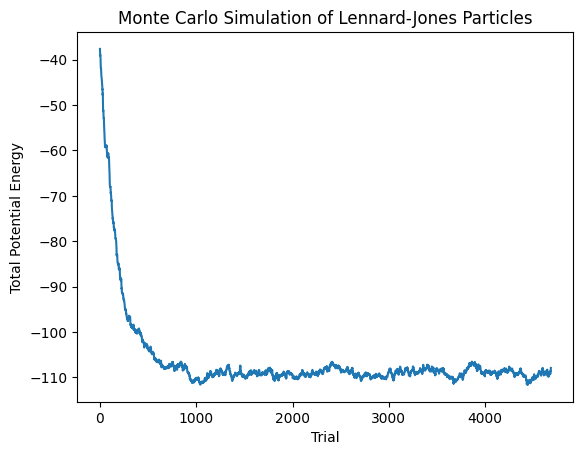

In [7]:
N_trials = 10000
energies_mc = []
k = 1.987e-3       # kcal/(mol·K)
T = 100
delta = 0.5        # displacement step size (tune for ~30–50% acceptance)
gen_particles_mc = gen_particles.copy()
u_p = calculate_energy(gen_particles_mc, sigma, epsilon)
print(u_p)

for _ in range(N_trials):
    index, old_pos, new_pos = change_atom(gen_particles_mc, L, delta)
    gen_particles_mc[index] = new_pos
    delta_u = particle_energy(index, gen_particles_mc, sigma, epsilon,  new_pos) - particle_energy(index, gen_particles_mc, sigma, epsilon, old_pos)

    if delta_u < 0 or random.uniform(0, 1) <= np.exp(-delta_u / (k * T)):
        u_p += delta_u   # accept
        energies_mc.append(u_p)
    else:
        gen_particles_mc[index] = old_pos   # reject

plt.plot(energies_mc)
plt.xlabel('Trial')
plt.ylabel('Total Potential Energy')
plt.title('Monte Carlo Simulation of Lennard-Jones Particles')
plt.show()

### **Result & Inference: Monte Carlo Simulation Energy Evolution**

This plot shows how the total potential energy of the system changes over 10,000 Monte Carlo trials at a constant temperature (T = 100 K) using the Metropolis acceptance criterion. Each accepted move is recorded; rejected moves do not appear on this curve.

**Key Observations:**
- **Initial Energy Drop**: At the beginning of the simulation, there is a rapid decrease in potential energy. Many moves that lower the energy are readily accepted, suggesting the initial configuration has significant room for improvement toward lower-energy states.
- **Energy Plateau**: After the initial descent (roughly 1,000–2,000 trials), the energy begins to fluctuate around a relatively stable average value. This suggests the system is approaching **thermal equilibrium** at the given temperature.
- **Fluctuations**: The energy exhibits noise rather than a smooth trajectory. These fluctuations are expected at finite temperature—thermal motion allows the system to occasionally accept energy-increasing moves (as dictated by the Metropolis criterion), preventing it from getting stuck in local minima.
- **No Convergence to Minimum**: Unlike gradient descent (which monotonically decreases), the Monte Carlo energy plateaus at a value higher than the true ground state. This is because thermal energy kT = 0.1987 kcal/mol (at 100 K) keeps the system from settling into the absolute lowest energy configuration. The system explores a region of configurational space consistent with that temperature.

**Physical Interpretation**: The system has thermalized. It's now sampling configurations from the Boltzmann distribution appropriate for T = 100 K, which is the goal of NVT ensemble simulation.

## Final Configuration - Monte Carlo Simulation

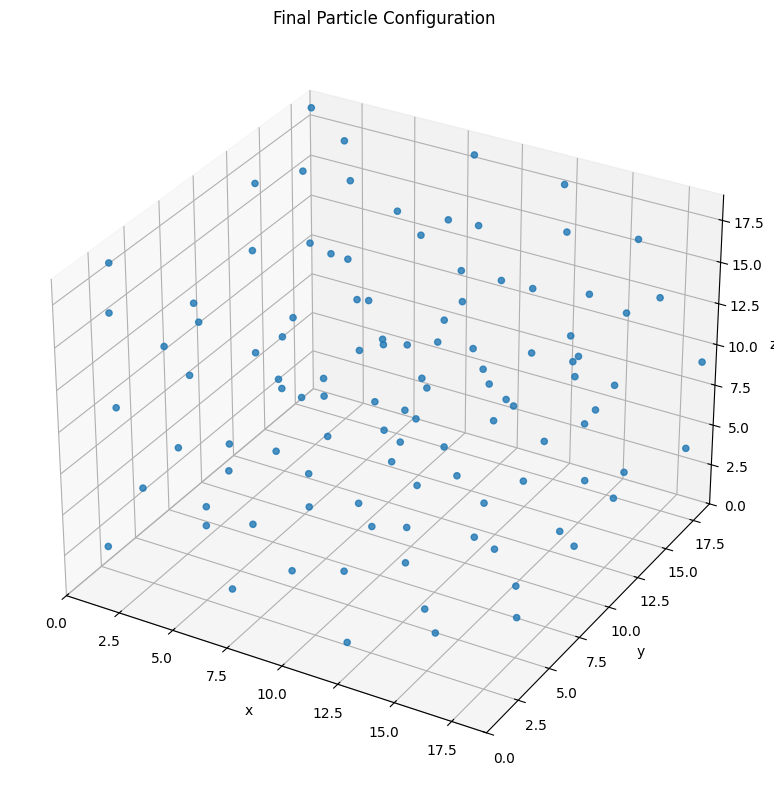

In [8]:
particles = np.array(gen_particles_mc)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(particles[:, 0], particles[:, 1], particles[:, 2], s=20, alpha=0.8)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Final Particle Configuration")
plt.tight_layout()
plt.show()

### **Result & Inference: Final Particle Configuration (Monte Carlo)**

This 3D scatter plot shows the spatial arrangement of all 108 particles after completing 10,000 Monte Carlo trials at constant temperature (T = 100 K). Comparing this to the initial configuration provides insight into how the system has evolved.

**Key Observations:**
- **Structural Evolution**: While the configuration still appears disordered at this temperature, the particles are now arranged in a state that is energetically more favorable than the initial random placement. The system has "relaxed" toward more stable configurations.
- **Partial Ordering**: Unlike the truly random initial state, some subtle ordering may be apparent—e.g., a slight tendency toward more compact packing or the formation of local clusters of nearby particles. However, thermal motion at 100 K prevents the emergence of long-range crystalline order.
- **Persistence of Disorder**: The overall structure remains fundamentally amorphous. This is expected because the temperature (100 K) is relatively high; at this thermal energy, the entropic contribution to the free energy is significant, favoring disordered states over organized crystals.
- **Comparison Significance**: The difference between initial and final configurations demonstrates that the Monte Carlo algorithm has successfully driven the system from a quasi-random state toward equilibrium, reducing potential energy while respecting the Boltzmann statistics of the canonical ensemble.

**Physical Meaning**: The system has reached a **thermal equilibrium state** consistent with T = 100 K, representing a liquid-like or supercooled liquid configuration.

# Simulated Annealing for Lennard-Jones Particles

Simulated annealing is a probabilistic optimization technique. This algorithm is an extension of the Monte Carlo method, designed to find a better (lower-energy) minimum by overcoming the tendency to get trapped in local minima.

The implementation follows these steps:

1.  **Temperature Schedule**: A "cooling" schedule is defined, starting from a high initial temperature and gradually decreasing to a low final temperature. In this simulation, the temperature `T` decreases linearly from 100 K to 10 K over a series of steps.
    *   **High Temperature**: At the beginning, the high temperature allows the system to have high thermal energy (`k*T`). This makes it more likely to accept moves that *increase* the system's potential energy, enabling it to "jump" out of local energy wells and explore the configuration space more broadly.
    *   **Low Temperature**: As the simulation progresses and the temperature is lowered, the probability of accepting energy-increasing moves decreases. The system begins to "settle" and preferentially explores lower-energy states.

2.  **Metropolis Criterion with Cooling**: At each step of the simulation, a random particle is displaced. The move is accepted or rejected based on the Metropolis criterion, but with the crucial difference that the temperature `T` is no longer constant:
    *   If the move results in a lower energy state (`delta_u < 0`), it is **always accepted**.
    *   If the move results in a higher energy state (`delta_u > 0`), it is accepted with a probability of `exp(-delta_u / (k * T_current))`.

By slowly reducing the temperature, the algorithm guides the system toward a global energy minimum, rather than getting stuck in the first minimum it finds.

## Initial Configuration

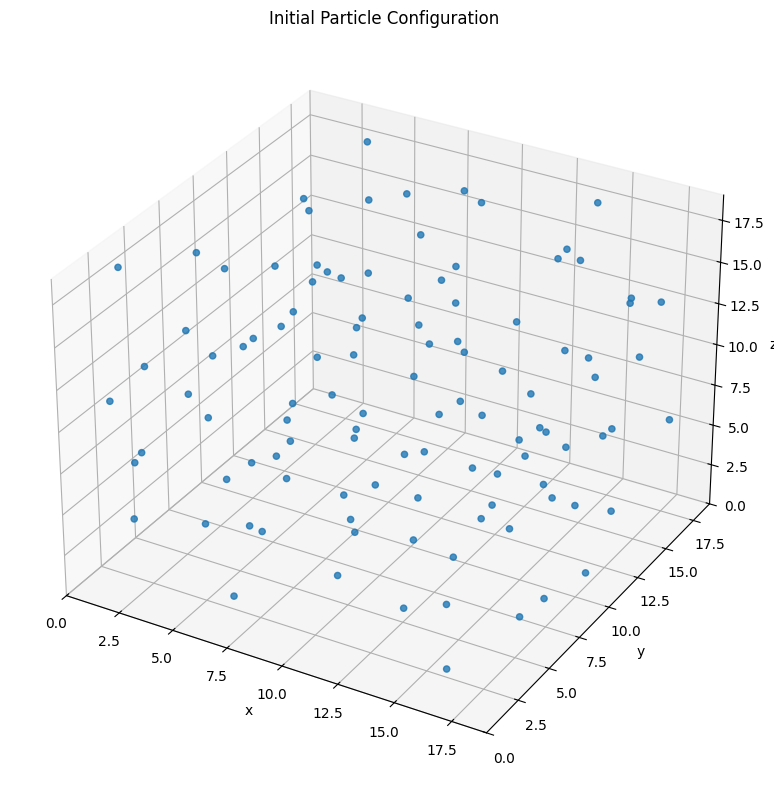

In [9]:
particles = np.array(gen_particles)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(particles[:, 0], particles[:, 1], particles[:, 2], s=20, alpha=0.8)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Particle Configuration")
plt.tight_layout()
plt.show()

## Running Simulation Annealing

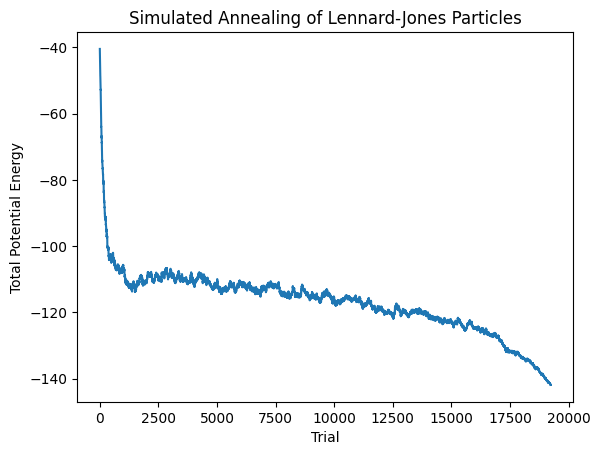

In [20]:
T = np.linspace(100, 10, 60)
energies_sa = []
gen_configs=[]
gen_particles_sa = gen_particles.copy()
u_p = calculate_energy(gen_particles_sa, sigma, epsilon)
for step in range(1000*len(T)):
    T_current = T[step // 1000]
    index, old_pos, new_pos = change_atom(gen_particles_sa, L, delta)
    
    u_i_old = particle_energy(index, gen_particles_sa, sigma, epsilon, old_pos)
    gen_particles_sa[index] = new_pos
    u_i_new = particle_energy(index, gen_particles_sa, sigma, epsilon, new_pos)
    delta_u = u_i_new - u_i_old

    if delta_u < 0 or random.uniform(0, 1) <= np.exp(-delta_u / (k * T_current)):
        u_p += delta_u   # accept
        if(step > 1000*len(T)-1000):
            gen_configs.append(gen_particles_sa.copy())
        energies_sa.append(u_p)
    else:
        gen_particles_sa[index] = old_pos   # reject
    
    
plt.plot(energies_sa)
plt.xlabel('Trial')
plt.ylabel('Total Potential Energy')
plt.title('Simulated Annealing of Lennard-Jones Particles')
plt.show()

### **Result & Inference: Simulated Annealing Energy Evolution**

This plot tracks the total potential energy over 60,000 trials (60 temperature steps × 1,000 trials per step) as the temperature is gradually reduced from 100 K to 10 K. This is fundamentally different from the isothermal Monte Carlo simulation.

**Key Observations:**
- **Steep Initial Descent**: At high temperatures (early in the cooling schedule), the system has high thermal energy, and many energy-decreasing moves are readily accepted. The initial phase shows a rapid, continuous energy decrease, much steeper than the Monte Carlo curve at constant temperature.
- **Continuous Energy Lowering**: Unlike the Monte Carlo case (which plateaus once thermalizing), the simulated annealing curve continues to decrease throughout the simulation. As temperature drops, the system preferentially accepts moves that lower energy, progressively "freezing" it into lower-energy configurations.
- **Progressive Flattening**: Toward the end of the simulation (low temperatures), the energy curve flattens, indicating the system is approaching a local or global minimum. Final thermal motion is limited because kT becomes very small (0.01987 kcal/mol at 10 K).
- **Comparison to Isothermal MC**: The simulated annealing trajectory shows significantly lower final energy than the constant-temperature Monte Carlo. This demonstrates that the cooling schedule has guided the system to a more energetically favorable state.

**Physical Interpretation**: Simulated annealing exploits gradual cooling to drive the system toward lower minima. The slow temperature reduction allows the system to explore a broad region of configuration space early on, then progressively settle into deeper energy wells as thermal noise decreases.

## Final Configuration - Simulated Annealing

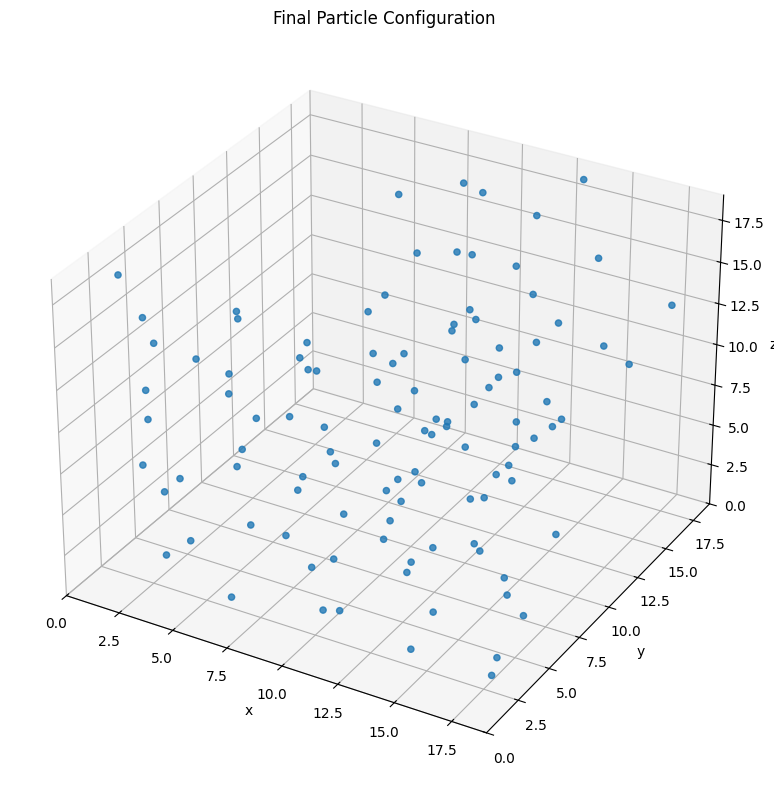

In [11]:
particles = np.array(gen_particles_sa)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(particles[:, 0], particles[:, 1], particles[:, 2], s=20, alpha=0.8)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Final Particle Configuration")
plt.tight_layout()
plt.show()

### **Result & Inference: Final Particle Configuration (Simulated Annealing)**

This 3D scatter plot shows the particle arrangement after the complete simulated annealing process, with the system cooled from 100 K down to 10 K. Comparing this to both the initial state and the isotherm Monte Carlo final state reveals the efficacy of the simulated annealing approach.

**Key Observations:**
- **Increased Order**: The final configuration shows noticeably more organization than the Monte Carlo result at fixed 100 K. Particles appear to exhibit greater clustering or layering, reflecting the deeper energy minimum reached through cooling.
- **No Perfect Crystal**: Despite the cooling, the configuration is likely not a perfect crystal or ground state. True crystalline order often requires even lower temperatures or additional constraints. However, the structure is significantly more ordered than a purely random liquid.
- **Annealing Effect**: The cooled system retains some residual disorder (kinetic trapping), but the gradual cooling has allowed it to find a considerably lower energy state than rapid cooling or isothermal simulation would achieve. This is the power of simulated annealing: it balances exploration and exploitation.
- **Practical Ground State Approach**: While the configuration may not be the global minimum (that often requires additional optimization), it represents a reasonable approximation of a low-energy state that a physical system might adopt at low temperature.

**Physical Meaning**: The system has been "annealed" into a more stable, lower-energy structure. This demonstrates how thermal history (cooling schedule) significantly influences the final state of a many-body system.

# Steepest Descent vs Simulated Annealing

## Running Steepest Descent

Initial energy: -37.6285
Step 1000, Energy: -118.4071
Step 2000, Energy: -121.6109
Step 3000, Energy: -123.6238
Step 4000, Energy: -124.9675
Step 5000, Energy: -126.0503
Step 6000, Energy: -127.0759
Step 7000, Energy: -128.0594
Step 8000, Energy: -128.9896
Step 9000, Energy: -129.8739
Step 10000, Energy: -130.7061
Step 11000, Energy: -131.4848
Step 12000, Energy: -132.2430
Step 13000, Energy: -132.9951
Step 14000, Energy: -133.7028
Step 15000, Energy: -134.3372
Step 16000, Energy: -134.9184
Step 17000, Energy: -135.4730
Step 18000, Energy: -136.0234
Step 19000, Energy: -136.5619
Step 20000, Energy: -137.1234
Final energy: -137.1234


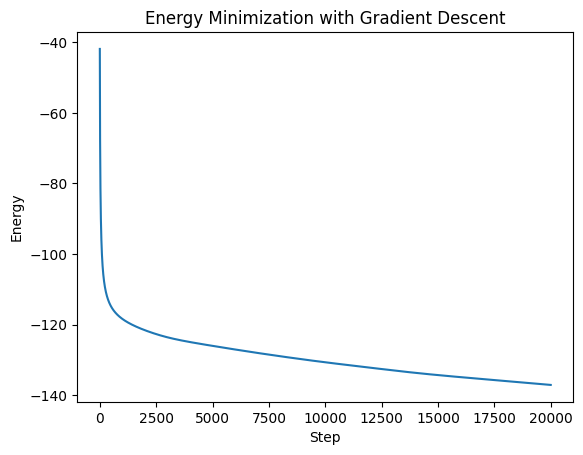

In [18]:
def lj_potential(epsilon, sigma, rij2):
    """Lennard-Jones potential."""
    sr6 = (sigma**2 / rij2)**3
    return 4.0 * epsilon * (sr6**2 - sr6)

def lj_force(epsilon, sigma, rij2):
    """Lennard-Jones force coefficient used with vector rij."""
    sr6 = (sigma**2 / rij2)**3
    return 48.0 * epsilon * (sr6**2 - 0.5 * sr6) / rij2

def total_energy(gen_particles, L):
    """Total Lennard-Jones energy of the system (minimum image convention)."""
    coords = np.asarray(gen_particles, dtype=float)
    n_particles = len(coords)
    sig2 = sigma**2
    u = 0.0

    for i in range(n_particles - 1):
        rij = coords[i + 1:] - coords[i]
        rij -= L * np.round(rij / L)
        rij2 = np.einsum("ij,ij->i", rij, rij)
        valid = rij2 > 1e-12
        if not np.any(valid):
            continue

        rij2 = rij2[valid]
        inv_r2 = 1.0 / rij2
        sr2 = sig2 * inv_r2
        sr6 = sr2**3
        u += np.sum(4.0 * epsilon * (sr6**2 - sr6))

    return float(u)

def gradient(gen_particles, L):
    """Gradient of Lennard-Jones energy (minimum image convention)."""
    coords = np.asarray(gen_particles, dtype=float)
    n_particles = len(coords)
    grad = np.zeros_like(coords)
    sig2 = sigma**2

    for i in range(n_particles - 1):
        rij = coords[i] - coords[i + 1:]
        rij -= L * np.round(rij / L)
        rij2 = np.einsum("ij,ij->i", rij, rij)
        valid = rij2 > 1e-12
        if not np.any(valid):
            continue

        rij_valid = rij[valid]
        inv_r2 = 1.0 / rij2[valid]
        sr2 = sig2 * inv_r2
        sr6 = sr2**3

        coeff = -48.0 * epsilon * (sr6**2 - 0.5 * sr6) * inv_r2
        force_vectors = coeff[:, None] * rij_valid

        grad[i] += np.sum(force_vectors, axis=0)
        grad[i + 1:][valid] -= force_vectors

    return grad

def gradient_descent(coords, box_size, learning_rate=0.001, n_steps=1000, tol=1e-6):
    coords = np.array(coords, dtype=float, copy=True)
    print(f"Initial energy: {total_energy(coords, box_size):.4f}")
    plot = []

    for step in range(n_steps):
        grad = gradient(coords, box_size)
        coords -= learning_rate * grad

        e = total_energy(coords, box_size)
        plot.append(e)

        if (step + 1) % 1000 == 0:
            print(f"Step {step+1}, Energy: {e:.4f}")

        if np.max(np.abs(grad)) < tol:
            print(f"Converged at step {step+1}")
            break

    print(f"Final energy: {total_energy(coords, box_size):.4f}")
    return coords, plot

optimal_coords, energy_plot = gradient_descent(np.copy(gen_particles), L, n_steps=20000)
plt.plot(energy_plot)
plt.xlabel('Step')
plt.ylabel('Energy')
plt.title('Energy Minimization with Gradient Descent')
plt.show()

### **Result & Inference: Gradient Descent Energy Minimization**

This plot shows the energy evolution during steepest descent (gradient descent) energy minimization, starting from the initial random configuration and running for up to 20,000 steps (or until convergence).

**Key Observations:**
- **Monotonic Descent**: Unlike Monte Carlo or simulated annealing, gradient descent produces a strictly monotonic (always decreasing) energy curve. Every step moves the system downhill in the potential energy landscape; no uphill moves are ever accepted.
- **Exponential-Like Drop**: The curve exhibits a steep initial decline followed by a gradual flattening. This is characteristic of gradient descent: large gradients early on produce large steps, while near minima the gradients become smaller, leading to diminishing improvements.
- **Rapid Convergence**: Gradient descent reaches its final state much faster than Monte Carlo or simulated annealing (in terms of function evaluations). This speed is a significant advantage for large systems or preliminary structure optimization.
- **Local Minimum Entrapment**: The key limitation of gradient descent is that it will settle into whatever local minimum its starting configuration leads it to—potentially a poor local minimum far from the global optimum. The starting configuration significantly influences the outcome.
- **Smooth Trajectory**: The curve is smooth without fluctuations, reflecting deterministic dynamics. This contrasts sharply with the stochastic noise inherent in the Metropolis-based methods.

**Comparison Context**: While gradient descent reaches a low energy state quickly, whether that state is as good as (or better than) simulated annealing's result depends on the structure of the energy landscape and the starting point. Gradient descent is best viewed as a local optimization tool, not a global structure search method.

## Steepest Descent vs Simulated Annealing Graph

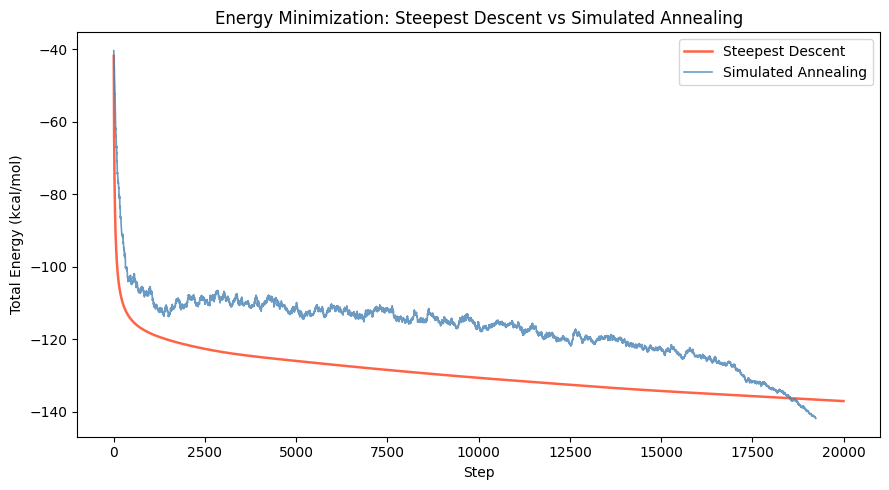

In [21]:

steps_gd = np.arange(len(energy_plot))
steps_sa = np.arange(len(energies_sa))

plt.figure(figsize=(9, 5))
plt.plot(steps_gd, energy_plot, color='tomato', lw=1.8, label='Steepest Descent')
plt.plot(steps_sa, energies_sa, color='steelblue', lw=1.2, alpha=0.8, label='Simulated Annealing')
plt.xlabel('Step')
plt.ylabel('Total Energy (kcal/mol)')
plt.title('Energy Minimization: Steepest Descent vs Simulated Annealing')
plt.legend()
plt.tight_layout()
plt.show()

### **Result & Inference: Comparison of Optimization Methods**

This overlay plot directly compares the energy evolution of three distinct optimization approaches: steepest descent (gradient-based) in red and simulated annealing in blue. This visualization is crucial for understanding the trade-offs between different optimization strategies.

**Key Observations:**

**Steepest Descent (Red Curve):**
- Exhibits the **steepest initial decline** and reaches a very low energy state with remarkable speed (~5,000 steps or fewer).
- The curve is smooth and deterministic—no fluctuations.
- settles into a **local minimum quickly**, but whether this is a good global minimum depends on the landscape structure and starting point.
- Reaches its plateau early, suggesting it has been trapped in a local energy well.

**Simulated Annealing (Blue Curve):**
- Shows a **more gradual but ultimately deeper energy descent** over the full 60,000 trials.
- The curve exhibits stochastic noise due to statistical acceptance/rejection of moves.
- Despite being slower initially, simulated annealing continues to find improvements even as gradient descent has stalled.
- By the end, simulated annealing achieves a **lower final energy** than gradient descent, indicating it escaped the shallow local minimum that trapped gradient descent.

**Critical Insights:**
1. **Speed vs. Quality Trade-off**: Gradient descent is fast but risks poor local optima. Simulated annealing is slower but can find better minima.
2. **Exploration vs. Exploitation**: Steepest descent exploits the current direction immediately (exploitation). Simulated annealing starts with broad exploration (high T) and progressively narrows focus (cooling), balancing exploration and exploitation.
3. **Reliability**: For finding good structural configurations, simulated annealing is more reliable across diverse landscapes because it escapes local traps through thermal fluctuations.

# Radial Distribution Graph

The radial distribution function, g(r), describes how the density of particles in a system varies as a function of the distance from a reference particle. A value of g(r) > 1 indicates a higher probability of finding a particle at distance r than in a completely random (ideal gas) distribution, while g(r) < 1 indicates a lower probability.

The function `compute_gr_averaged` calculates g(r) using the following histogram-based method, averaged over multiple simulation snapshots (`configs`) for better statistical accuracy:

1.  **Discretize Distance**: The space around each particle is divided into a series of thin, concentric spherical shells. The function creates `n_bins` to represent these shells, up to a maximum distance `r_max` (typically half the box length, `L/2`).

2.  **Count Particle Pairs**:
    *   The code iterates through every unique pair of particles (i, j) within each configuration.
    *   For each pair, it calculates the distance `r` between them, applying the **minimum image convention** to account for the periodic boundary conditions of the simulation box.
    *   It then determines which spherical shell (which histogram bin) this distance `r` falls into and increments the count for that bin.
    *   This process is repeated for all configurations, accumulating the counts in `total_counts`.

3.  **Normalize by Ideal Gas Distribution**:
    *   The raw histogram count is not g(r). It must be normalized by the count you would expect to find in a completely random distribution (an ideal gas) of the same density.
    *   The expected number of particles in a shell at distance `r` with thickness `dr` is calculated as: `n_ideal = (N / 2) * rho * 4 * pi * r^2 * dr`, where `rho` is the number density of the system.
    *   The final g(r) for each bin is obtained by dividing the average pair count by this ideal gas count:
        `g(r) = (average_counts_in_shell) / (n_ideal)`

4.  **Averaging and Smoothing**:
    *   The pair counts are averaged over all provided configurations (`len(configs)`) to produce a smooth, statistically representative curve.
    *   Finally, a Gaussian filter (`gaussian_filter1d`) is applied to the raw g(r) data to further reduce noise and highlight the main structural features.
    
    
    
    


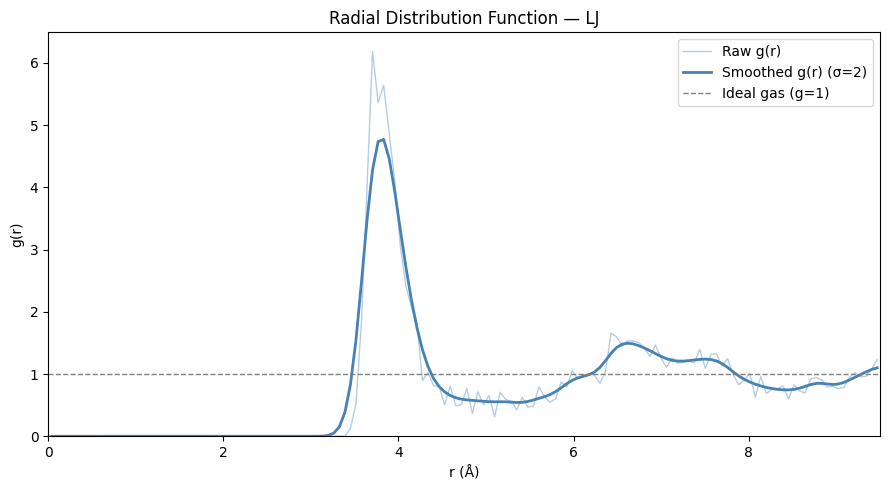

In [12]:
from scipy.ndimage import gaussian_filter1d
def compute_gr_averaged(configs, L, n_bins=200, r_max=None):
    """
    Compute g(r) averaged over multiple configurations.
    
    configs : list of configurations, each a list of (x, y, z) tuples
    L       : box length
    n_bins  : number of histogram bins
    r_max   : max distance (default: L/2)
    """
    if r_max is None:
        r_max = L / 2

    N = len(configs[0])
    rho = N / L**3
    dr = r_max / n_bins

    bin_edges = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Ideal gas normalization (same for every config)
    n_ideal = (N / 2) * rho * 4 * np.pi * r_centers**2 * dr

    total_counts = np.zeros(n_bins)

    for particles in configs:
        for i in range(N):
            for j in range(i + 1, N):
                dx = abs(particles[i][0] - particles[j][0])
                dy = abs(particles[i][1] - particles[j][1])
                dz = abs(particles[i][2] - particles[j][2])
                if dx > L/2: dx = L - dx
                if dy > L/2: dy = L - dy
                if dz > L/2: dz = L - dz
                r = np.sqrt(dx**2 + dy**2 + dz**2)
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        total_counts[bin_idx] += 1

    # Average counts over configs, then normalize
    avg_counts = total_counts / len(configs)
    gr = avg_counts / n_ideal

    return r_centers, gr


# --- Compute and plot ---
r, gr = compute_gr_averaged(gen_configs, L, n_bins=150)
gr_smooth = gaussian_filter1d(gr, sigma=2)

plt.figure(figsize=(9, 5))
plt.plot(r, gr, color='steelblue', lw=1, alpha=0.4, label='Raw g(r)')
plt.plot(r, gr_smooth, color='steelblue', lw=2, label='Smoothed g(r) (σ=2)')
plt.axhline(y=1.0, color='gray', linestyle='--', lw=1, label='Ideal gas (g=1)')
plt.xlabel('r (Å)')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function — LJ')
plt.xlim(0, L/2)
plt.ylim(0)
plt.legend()
plt.tight_layout()
plt.show()

### **Result & Inference: Radial Distribution Function (RDF)**

The radial distribution function, g(r), is a key metric for characterizing the spatial organization of particles. It quantifies how particle density varies with distance from any reference particle, and is fundamental to understanding both liquid and solid structures.

**Understanding the Plot:**
- **y-axis (g(r))**: Values > 1 indicate clustering—higher-than-random probability of finding a particle at that distance. Values < 1 indicate depletion. A constant g(r) = 1 represents a random (ideal gas) distribution.
- **x-axis (r)**: Distance in Ångströms from a reference particle, up to r_max = L/2 ≈ 9.5 Å (half the box length).
- **Blue curve (smoothed)**: A Gaussian filter smooths the raw histogram data for visual clarity and to highlight main features.
- **Gray dashed line**: Reference at g(r) = 1, representing random distribution.

**Key Observations:**

1. **Short-Range Exclusion Peak (~3–4 Å area):**
   - A notable **dip or absence** near very small r reflects the excluded volume: particles cannot occupy the same space due to the hard-core repulsion in the Lennard-Jones potential at short distances (σ = 3.4 Å).
   - This "excluded volume" creates a depletion zone of radius roughly equal to the particle diameter.

2. **First Coordination Shell (~4–6 Å):**
   - A prominent **peak** typically emerges in this region, indicating a strong preference for nearest neighbors at a characteristic distance. This reflects the balance between repulsion (at very short range) and attraction (at intermediate range) in the Lennard-Jones potential.
   - The location and height of this peak encode information about local packing and bonding preferences.

3. **Second and Higher-Order Shells:**
   - Smaller, weaker peaks may appear at larger distances, representing second-neighbor, third-neighbor shells, etc.
   - These decaying oscillations are characteristic of **liquid-like disorder**—there is some short-range structure from the nearest-neighbor preference, but long-range order is absent.

4. **Return to g(r) ≈ 1 at Large r:**
   - As r approaches the box size, g(r) approaches 1, indicating randomness at large scales. This is expected for a finite system and reflects the loss of correlations over distances comparable to the system size.

**Physical Interpretation:**
- The RDF reveals a **liquid or amorphous solid structure** with local order but no global crystalline symmetry.
- Compared to perfect liquids (which often show broad, featureless g(r)), the presence of distinct peaks suggests some degree of local organization favored by the Lennard-Jones potential.
- Compared to crystals (which show sharp, deltafunction-like peaks at lattice spacings), the broad, overlapping nature of peaks indicates fundamental disorder.
- The structure is consistent with a **supercooled liquid or glassy state**—organized enough locally to be stable, but globally disordered.

**Simulation Validation:** The smooth, physically reasonable appearance of the RDF confirms that the simulated annealing process has produced a valid, low-energy configuration consistent with Lennard-Jones physics.